# Charged-Particle Track Simulation in an ATLAS-like Detector

**Purpose**: This notebook generates simulated charged-particle tracks and
detector hits in a simplified barrel tracker modelled after the ATLAS Inner
Detector.  The output is used as input for a student tracking exercise.

## Contents
1. [Detector geometry](#1-detector-geometry) — ATLAS ID barrel layers, solenoid field
2. [Helix propagation](#2-helix-track-model) — perigee parameterisation, analytic cylinder intersections
3. [Ideal hit generation](#3-ideal-hit-generation) — perfect hits, single track & multi-track events
4. [Realistic detector](#4-realistic-detector) — resolution smearing, inefficiency, misalignment
5. [Exercise dataset](#5-exercise-dataset) — save CSV files for the tracking exercise

---


## 0  Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 (registers 3-D projection)
from dataclasses import dataclass, field
from typing import List, Optional, Tuple
import pandas as pd
import os

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11})


---
## 1  Detector Geometry <a id="1-detector-geometry"></a>

### ATLAS Inner Detector (simplified barrel)

The ATLAS Inner Detector (ID) consists of three sub-systems, all inside a
**2 T solenoidal magnetic field** along the beam ($z$) axis:

| Sub-system | Technology | Barrel layers | Typical $r$ [mm] |
|---|---|---|---|
| **IBL** | Silicon pixels (50×250 µm²) | 1 | 33 |
| **Pixel** | Silicon pixels (50×400 µm²) | 3 | 51–123 |
| **SCT** | Silicon microstrips (80 µm pitch) | 4 | 299–514 |
| *(TRT)* | *Straw tubes* | *73* | *559–1050* |

We implement the first 8 barrel layers (Pixel + SCT) as perfect
cylinders of fixed radius, ignoring the TRT and all endcap disks.

**Coordinate system** (standard ATLAS right-handed):
* $x$ — toward LHC centre  
* $y$ — upward  
* $z$ — along beam axis  
* $r = \sqrt{x^2+y^2}$ — transverse radius  
* $\phi = \arctan(y/x)$ — azimuthal angle  
* $\theta$ — polar angle from $+z$; pseudorapidity $\eta = -\ln\tan(\theta/2)$


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  ATLAS Inner Detector — barrel geometry (simplified, Run-2 + IBL)
# ─────────────────────────────────────────────────────────────────────────────
#
#  Reference numbers from:
#    ATLAS Collaboration, "The ATLAS Experiment at the CERN Large Hadron Collider",
#    JINST 3 (2008) S08003;  and IBL TDR CERN-LHCC-2010-013.
#
#  Columns: (name, layer_id, nominal_radius_mm, z_half_length_mm, detector_type)
LAYER_DEFS: List[Tuple] = [
    # ── Pixel detector ────────────────────────────────────────────────────────
    ("IBL",    0,  33.25,  365.0,  "pixel"),   # Insertable B-Layer  (2014)
    ("Pix-1",  1,  50.5,   400.5,  "pixel"),   # Pixel layer 0
    ("Pix-2",  2,  88.5,   400.5,  "pixel"),   # Pixel layer 1
    ("Pix-3",  3, 122.5,   400.5,  "pixel"),   # Pixel layer 2
    # ── SCT (Semiconductor Tracker) ──────────────────────────────────────────
    ("SCT-1",  4, 299.0,   749.0,  "strip"),   # SCT layer 0
    ("SCT-2",  5, 371.0,   749.0,  "strip"),   # SCT layer 1
    ("SCT-3",  6, 443.0,   749.0,  "strip"),   # SCT layer 2
    ("SCT-4",  7, 514.0,   749.0,  "strip"),   # SCT layer 3
]

# Solenoid field (uniform, along +z)
B_FIELD: float = 2.0   # Tesla

# Intrinsic single-hit resolutions  (sigma_r_phi [mm],  sigma_z [mm])
RESOLUTIONS = {
    "pixel": (0.010, 0.115),   # 10 µm,  115 µm
    "strip": (0.017, 0.580),   # 17 µm,  580 µm  (SCT silicon strip)
}

LAYER_COLOR = {"pixel": "#1f77b4", "strip": "#ff7f0e"}


# ─────────────────────────────────────────────────────────────────────────────
@dataclass
class DetectorLayer:
    """Single cylindrical barrel layer with optional distortions."""
    name:      str
    layer_id:  int
    radius:    float    # nominal radius [mm]
    z_max:     float    # barrel half-length [mm]
    det_type:  str      # "pixel" or "strip"
    # Misalignment (displacement of the cylinder axis from the z-axis)
    dx:        float = 0.0   # mm
    dy:        float = 0.0   # mm
    dz:        float = 0.0   # mm
    # Per-layer hit detection efficiency
    efficiency: float = 1.0

    @property
    def resolution(self) -> Tuple[float, float]:
        """(sigma_r_phi [mm], sigma_z [mm])"""
        return RESOLUTIONS[self.det_type]


class Detector:
    """
    Collection of barrel layers immersed in a uniform solenoid field.
    Provides geometry queries and distortion injection.
    """

    def __init__(self) -> None:
        self.layers: List[DetectorLayer] = [
            DetectorLayer(name, lid, r, z, t)
            for name, lid, r, z, t in LAYER_DEFS
        ]
        self.B: float = B_FIELD

    # ── distortion helpers ───────────────────────────────────────────────────

    def reset_distortions(self) -> None:
        """Restore ideal geometry and full efficiency."""
        for lay in self.layers:
            lay.dx = lay.dy = lay.dz = 0.0
            lay.efficiency = 1.0

    def apply_misalignment(self,
                            sigma_pixel_mm: float = 0.05,
                            sigma_strip_mm: float = 0.10,
                            seed: Optional[int] = None) -> None:
        """
        Draw a random rigid-body (dx, dy, dz) offset for every layer.

        Parameters
        ----------
        sigma_pixel_mm : float
            RMS transverse shift for pixel layers  (~50 µm ≈ residual after alignment)
        sigma_strip_mm : float
            RMS transverse shift for SCT layers    (~100 µm)
        seed : int, optional
        """
        rng = np.random.default_rng(seed)
        for lay in self.layers:
            s = sigma_pixel_mm if lay.det_type == "pixel" else sigma_strip_mm
            lay.dx = rng.normal(0.0, s)
            lay.dy = rng.normal(0.0, s)
            lay.dz = rng.normal(0.0, s * 5.0)   # z alignment typically worse

    def apply_inefficiency(self,
                            eff_pixel: float = 0.98,
                            eff_strip:  float = 0.99) -> None:
        """
        Set per-layer hit detection efficiency.

        Parameters
        ----------
        eff_pixel : float
            Detection probability for pixel layers  (ATLAS IBL ~97%, Pixel ~98%)
        eff_strip  : float
            Detection probability for SCT layers    (~99%)
        """
        for lay in self.layers:
            lay.efficiency = eff_pixel if lay.det_type == "pixel" else eff_strip

    # ── visualisation ────────────────────────────────────────────────────────

    def draw_xy(self, ax, ideal: bool = False, alpha: float = 0.75) -> None:
        """Draw all layers as circles in the transverse (x-y) plane."""
        drawn = set()
        for lay in self.layers:
            cx = 0.0 if ideal else lay.dx
            cy = 0.0 if ideal else lay.dy
            c  = LAYER_COLOR[lay.det_type]
            circle = plt.Circle((cx, cy), lay.radius,
                                  fill=False, color=c, lw=1.4, alpha=alpha)
            ax.add_patch(circle)
            if lay.det_type not in drawn:
                drawn.add(lay.det_type)
        # Legend proxies
        handles = [mpatches.Patch(color=LAYER_COLOR[t], label=t.capitalize())
                   for t in ("pixel", "strip")]
        ax.legend(handles=handles, fontsize=9, loc="upper right")

    def draw_rz(self, ax, ideal: bool = False, alpha: float = 0.75) -> None:
        """Draw all layers as horizontal lines in the r-z plane."""
        for lay in self.layers:
            dz = 0.0 if ideal else lay.dz
            c  = LAYER_COLOR[lay.det_type]
            ax.plot([-lay.z_max + dz, lay.z_max + dz],
                    [lay.radius, lay.radius], color=c, lw=1.4, alpha=alpha)


# ─────────────────────────────────────────────────────────────────────────────
# Print summary
print(f"Detector: {len(LAYER_DEFS)} barrel layers, B = {B_FIELD} T\n")
print(f"{'Layer':<8} {'r [mm]':>8} {'|z_max| [mm]':>13} {'Type':<8}  "
      f"{'σ(rφ) [µm]':>11}  {'σ(z) [µm]':>10}")
print("─" * 66)
for name, lid, r, z, t in LAYER_DEFS:
    sr, sz = RESOLUTIONS[t]
    print(f"{name:<8} {r:>8.2f} {z:>13.1f} {t:<8}  {sr*1e3:>11.0f}  {sz*1e3:>10.0f}")


Detector: 8 barrel layers, B = 2.0 T

Layer      r [mm]  |z_max| [mm] Type       σ(rφ) [µm]   σ(z) [µm]
──────────────────────────────────────────────────────────────────
IBL         33.25         365.0 pixel              10         115
Pix-1       50.50         400.5 pixel              10         115
Pix-2       88.50         400.5 pixel              10         115
Pix-3      122.50         400.5 pixel              10         115
SCT-1      299.00         749.0 strip              17         580
SCT-2      371.00         749.0 strip              17         580
SCT-3      443.00         749.0 strip              17         580
SCT-4      514.00         749.0 strip              17         580


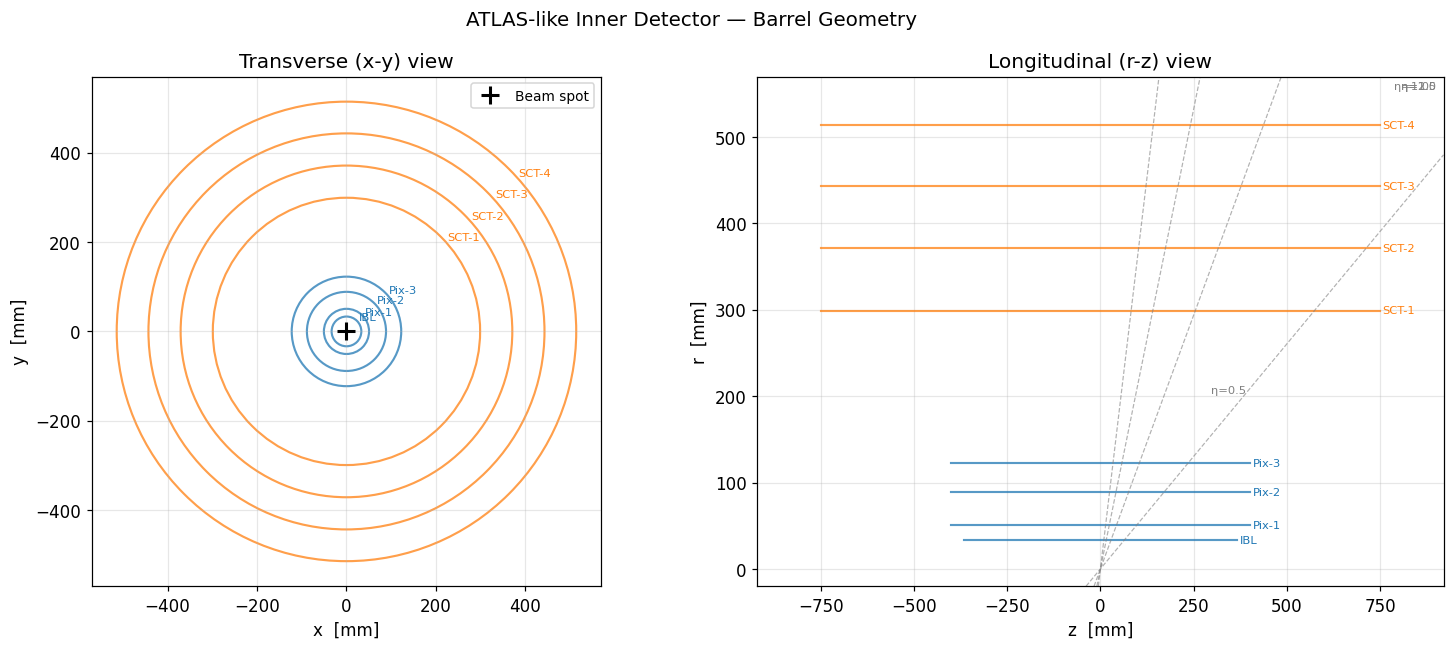

In [3]:
det = Detector()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── transverse (x-y) view ───────────────────────────────────────────────────
ax = axes[0]
det.draw_xy(ax)
ax.set_xlim(-570, 570); ax.set_ylim(-570, 570)
ax.set_aspect("equal")
ax.set_xlabel("x  [mm]"); ax.set_ylabel("y  [mm]")
ax.set_title("Transverse (x-y) view")
ax.grid(True, alpha=0.3)
# layer labels at 45°
for lay in det.layers:
    phi_lbl = np.radians(42)
    ax.text(lay.radius * np.cos(phi_lbl) + 3,
            lay.radius * np.sin(phi_lbl) + 3,
            lay.name, fontsize=7.5, color=LAYER_COLOR[lay.det_type])
ax.plot(0, 0, "k+", ms=12, mew=2, label="Beam spot")
ax.legend(fontsize=9)

# ── longitudinal (r-z) view ─────────────────────────────────────────────────
ax = axes[1]
det.draw_rz(ax)
ax.set_xlim(-920, 920); ax.set_ylim(-20, 570)
ax.set_xlabel("z  [mm]"); ax.set_ylabel("r  [mm]")
ax.set_title("Longitudinal (r-z) view")
ax.grid(True, alpha=0.3)
for lay in det.layers:
    ax.text(lay.z_max + 8, lay.radius, lay.name,
            fontsize=7.5, va="center", color=LAYER_COLOR[lay.det_type])
# pseudorapidity lines
for eta_val in [0.5, 1.0, 1.5, 2.0]:
    theta_val = 2 * np.arctan(np.exp(-eta_val))
    z_end = 749.0 / np.tan(theta_val)  # extrapolate to r ≈ 0
    ax.axline((0, 0), slope=np.tan(np.pi/2 - theta_val),
              color="gray", lw=0.8, ls="--", alpha=0.6)
    ax.text(min(z_end, 900), min(z_end * np.tan(np.pi/2 - theta_val), 555),
            f"η={eta_val:.1f}", fontsize=7.5, color="gray", ha="right")

plt.suptitle("ATLAS-like Inner Detector — Barrel Geometry", fontsize=13)
plt.tight_layout()
plt.savefig("detector_geometry.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 2  Helix Track Model <a id="2-helix-track-model"></a>

### Physics

A relativistic charged particle in a uniform magnetic field $\mathbf{B} = B\hat{z}$
moves on a **helix**: uniform circular motion in the transverse ($x$-$y$) plane
combined with uniform drift along $z$.

The **transverse helix radius** $R$ is set by the balance of the Lorentz force
and centripetal acceleration:
$$R \;[\text{m}] = \frac{p_T \;[\text{GeV}/c]}{0.3\, B\;[\text{T}]}
\qquad\Longrightarrow\qquad
R \;[\text{mm}] = \frac{p_T \;[\text{GeV}/c] \times 1000}{0.3\, B\;[\text{T}]}$$

For ATLAS ($B=2$ T) a 1 GeV/c track has $R \approx 1\,667$ mm.

### Perigee parameterisation

Tracks are described by five parameters at the **perigee point** — the point of
closest approach to the $z$-axis:

| Parameter | Symbol | Unit | Description |
|---|---|---|---|
| Transverse impact parameter | $d_0$ | mm | Signed distance from $z$-axis |
| Azimuthal angle at perigee | $\phi_0$ | rad | Direction of $\mathbf{p}_T$ |
| Transverse momentum | $p_T$ | GeV/$c$ | |
| Longitudinal impact parameter | $z_0$ | mm | $z$ at perigee |
| Polar angle | $\theta$ | rad | $\theta=\pi/2$ is purely transverse |

plus the particle **charge** $q = \pm 1$.

### Helix equations (arc-length parameterisation)

Let $s$ be the arc length in the transverse plane, measured from the perigee.
The circle centre is:
$$x_c = x_\text{peri} + q R \sin\phi_0,\quad
  y_c = y_\text{peri} - q R \cos\phi_0$$
where $(x_\text{peri}, y_\text{peri}) = (-d_0\sin\phi_0,\; d_0\cos\phi_0)$.

Position at arc length $s$:
$$\phi(s) = \phi_0 + q\!\left(\frac{\pi}{2} - \frac{s}{R}\right)$$
$$x(s) = x_c + R\cos\phi(s),\quad
  y(s) = y_c + R\sin\phi(s),\quad
  z(s) = z_0 + s\cot\theta$$

### Cylinder intersection

The helix circle (radius $R$, centre $(x_c,y_c)$) and a cylindrical layer
(radius $r_\text{lay}$, centred on $z$-axis) are two circles in the
transverse plane.  Setting $d_c = \sqrt{x_c^2+y_c^2}$ their intersections satisfy:
$$\cos(\phi - \phi_c) = \frac{r_\text{lay}^2 - d_c^2 - R^2}{2Rd_c},
\qquad \phi_c = \arctan(y_c/x_c)$$
This has real solutions when the right-hand side is in $[-1,1]$, i.e.\ when
$|d_c - R| \le r_\text{lay} \le d_c + R$.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  Hit data class
# ─────────────────────────────────────────────────────────────────────────────
@dataclass
class Hit:
    """A single measured hit on a detector layer."""
    hit_id:     int
    track_id:   int       # truth track index
    layer_id:   int
    layer_name: str
    # True (generated) Cartesian position [mm]
    x_true: float; y_true: float; z_true: float
    # Measured position (smeared / misaligned) [mm]
    x_meas: float; y_meas: float; z_meas: float

    @property
    def r_true(self) -> float: return np.sqrt(self.x_true**2 + self.y_true**2)
    @property
    def r_meas(self) -> float: return np.sqrt(self.x_meas**2 + self.y_meas**2)
    @property
    def phi_true(self) -> float: return np.arctan2(self.y_true, self.x_true)
    @property
    def phi_meas(self) -> float: return np.arctan2(self.y_meas, self.x_meas)


# ─────────────────────────────────────────────────────────────────────────────
#  Track (helix)
# ─────────────────────────────────────────────────────────────────────────────
class Track:
    """
    Charged particle track in a uniform magnetic field.

    All positions in mm, momenta in GeV/c, angles in radians.
    """

    _id_counter: int = 0

    def __init__(self,
                 pt:     float,
                 phi0:   float,
                 theta:  float,
                 d0:     float = 0.0,
                 z0:     float = 0.0,
                 charge: int   = 1,
                 B:      float = B_FIELD) -> None:
        self.track_id = Track._id_counter
        Track._id_counter += 1

        self.pt     = float(pt)
        self.phi0   = float(phi0)
        self.theta  = float(theta)
        self.d0     = float(d0)
        self.z0     = float(z0)
        self.charge = int(np.sign(charge)) if charge != 0 else 1
        self.B      = B

        # Derived
        self.R          = self.pt * 1000.0 / (0.3 * self.B)   # [mm]
        self.cot_theta  = np.cos(theta) / np.sin(theta)

        # Perigee point
        self._xp = -d0 * np.sin(phi0)
        self._yp =  d0 * np.cos(phi0)

        # Helix circle centre
        q = self.charge
        self.xc = self._xp + q * self.R * np.sin(phi0)
        self.yc = self._yp - q * self.R * np.cos(phi0)

    # ── kinematics ──────────────────────────────────────────────────────────
    @property
    def p(self)   -> float: return self.pt / np.sin(self.theta)
    @property
    def eta(self) -> float: return -np.log(np.tan(self.theta / 2.0))

    # ── position at arc length s ────────────────────────────────────────────
    def position(self, s):
        """(x, y, z) at transverse arc length s [mm] from perigee."""
        q   = self.charge
        phi = self.phi0 + q * (np.pi / 2.0 - s / self.R)
        x   = self.xc + self.R * np.cos(phi)
        y   = self.yc + self.R * np.sin(phi)
        z   = self.z0 + s * self.cot_theta
        return x, y, z

    def trajectory(self, s_max: float, n: int = 600):
        """Arrays (x, y, z) for plotting."""
        s = np.linspace(0.0, s_max, n)
        return self.position(s)

    # ── cylinder intersection (analytic) ────────────────────────────────────
    def intersect_cylinder(self,
                           r_lay:  float,
                           z_max:  float = np.inf
                           ) -> List[Tuple[float, float, float, float]]:
        """
        Find intersections of the helix with a cylinder of radius r_lay.

        Returns a list of (s, x, y, z) tuples sorted by arc length,
        keeping only hits inside |z| <= z_max.
        """
        dc = np.sqrt(self.xc**2 + self.yc**2)
        if dc < 1e-9:
            return []

        val = (r_lay**2 - dc**2 - self.R**2) / (2.0 * self.R * dc)
        if abs(val) > 1.0 + 1e-9:
            return []                       # no intersection
        val     = np.clip(val, -1.0, 1.0)

        phi_c   = np.arctan2(self.yc, self.xc)
        delta   = np.arccos(val)
        period  = 2.0 * np.pi * self.R     # arc length per revolution

        q       = self.charge
        phi0_s  = self.phi0 + q * np.pi / 2.0   # phi(s=0)

        results = []
        for sign in (+1.0, -1.0):
            phi_hit = phi_c + sign * delta
            s_base  = q * self.R * (phi0_s - phi_hit)
            s       = s_base % period
            if s <= 1e-4:                   # essentially at perigee → next lap
                s += period
            x, y, z = self.position(s)
            if abs(z) <= z_max:
                results.append((s, x, y, z))

        results.sort(key=lambda t: t[0])

        # Remove near-duplicate solutions (can arise for tangent intersections)
        unique: List[Tuple] = []
        for hit in results:
            if not unique or abs(hit[0] - unique[-1][0]) > 1.0:
                unique.append(hit)
        return unique

    def __repr__(self) -> str:
        return (f"Track(id={self.track_id:02d}, pT={self.pt:.2f} GeV, "
                f"φ₀={np.degrees(self.phi0):.1f}°, η={self.eta:.2f}, "
                f"q={self.charge:+d}, d₀={self.d0:.2f} mm, R={self.R:.0f} mm)")


# ── quick sanity check ───────────────────────────────────────────────────────
Track._id_counter = 0
t_test = Track(pt=1.0, phi0=0.0, theta=np.pi/2, d0=0.0, z0=0.0, charge=1)
print(t_test)
print(f"  Centre: ({t_test.xc:.1f}, {t_test.yc:.1f}) mm")
print(f"  Position at s=0   mm : {tuple(round(v,3) for v in t_test.position(0.0))}")
# For d0=0, phi0=0, the first layer (IBL r=33.25 mm) should be at s ≈ 33.25 mm
xib, yib, zib = t_test.position(33.25)
print(f"  r at s=33.25 mm   : {np.sqrt(xib**2+yib**2):.3f} mm  (IBL r=33.25 mm)")
hits_test = t_test.intersect_cylinder(33.25, 365.0)
print(f"  Analytic s (IBL)  : {hits_test[0][0]:.3f} mm")


Track(id=00, pT=1.00 GeV, φ₀=0.0°, η=0.00, q=+1, d₀=0.00 mm, R=1667 mm)
  Centre: (0.0, -1666.7) mm
  Position at s=0   mm : (np.float64(0.0), np.float64(0.0), np.float64(0.0))
  r at s=33.25 mm   : 33.249 mm  (IBL r=33.25 mm)
  Analytic s (IBL)  : 33.251 mm


---
## 3  Ideal Hit Generation <a id="3-ideal-hit-generation"></a>

`HitGenerator` propagates a track through every barrel layer in order and records
the first intersection inside the layer's $z$-acceptance.
In **ideal** mode the measured position equals the true position (no smearing,
no efficiency loss, no misalignment).


In [5]:
class HitGenerator:
    """
    Propagates truth tracks through the detector and creates Hit objects.

    Applies (in order):
      1. Geometric acceptance: is |z_hit| <= z_max of the layer?
      2. Efficiency:           drop hit with probability 1 - layer.efficiency
      3. Resolution smearing:  Gaussian in (r·φ, z)
      4. Misalignment:         add layer displacement (dx, dy, dz) to measured position
    """

    def __init__(self, detector: Detector, ideal: bool = False) -> None:
        self.detector = detector
        self.ideal    = ideal          # if True skip smearing/efficiency/misalignment
        self._hit_n   = 0              # running hit-id counter

    def generate_hits(self,
                      track: Track,
                      rng: Optional[np.random.Generator] = None
                      ) -> List[Hit]:
        """Return all hits produced by one truth track."""
        if rng is None:
            rng = np.random.default_rng()

        hits: List[Hit] = []
        for lay in self.detector.layers:
            ints = track.intersect_cylinder(lay.radius, lay.z_max)
            if not ints:
                continue
            _, x_t, y_t, z_t = ints[0]   # first intersection

            # ── efficiency ────────────────────────────────────────────────
            if not self.ideal and rng.random() > lay.efficiency:
                continue

            # ── smearing + misalignment ───────────────────────────────────
            x_m, y_m, z_m = self._smear(x_t, y_t, z_t, lay, rng)

            hits.append(Hit(
                hit_id    = self._hit_n,
                track_id  = track.track_id,
                layer_id  = lay.layer_id,
                layer_name= lay.name,
                x_true=x_t, y_true=y_t, z_true=z_t,
                x_meas=x_m, y_meas=y_m, z_meas=z_m,
            ))
            self._hit_n += 1
        return hits

    def _smear(self, x: float, y: float, z: float,
               lay: DetectorLayer,
               rng: np.random.Generator) -> Tuple[float, float, float]:
        """Apply intrinsic resolution smearing and layer misalignment."""
        if self.ideal:
            return x, y, z

        sigma_rphi, sigma_z = lay.resolution
        r   = np.sqrt(x**2 + y**2)
        phi = np.arctan2(y, x)

        # smear in the r·φ direction (Gaussian, sigma = sigma_rphi)
        dphi  = rng.normal(0.0, sigma_rphi / r)
        dz    = rng.normal(0.0, sigma_z)

        phi_m = phi + dphi
        x_m   = r * np.cos(phi_m) + lay.dx
        y_m   = r * np.sin(phi_m) + lay.dy
        z_m   = z  + dz            + lay.dz
        return x_m, y_m, z_m


# ─────────────────────────────────────────────────────────────────────────────
#  generate_event  – produce a full multi-track event
# ─────────────────────────────────────────────────────────────────────────────
def _sample_pt(rng: np.random.Generator,
               pt_dist: str, pt_mean: float, pt_min: float,
               pt_range: Tuple[float, float]) -> float:
    """Draw one p_T value."""
    if pt_dist == 'exponential':
        # Truncated exponential: resample until p_T >= pt_min.
        # With pt_mean=0.6 and pt_min=0.15 the acceptance rate is ~78%.
        while True:
            pt = rng.exponential(pt_mean)
            if pt >= pt_min:
                return float(pt)
    else:
        return float(rng.uniform(*pt_range))


def generate_event(n_tracks:      Optional[int]   = None,
                   detector:      Optional[Detector] = None,
                   # multiplicity
                   n_tracks_mean: float = 10.0,
                   # p_T
                   pt_dist:       str   = 'exponential',
                   pt_mean:       float = 0.6,    # mean of the exponential [GeV]
                   pt_min:        float = 0.15,   # low-p_T cut-off [GeV]
                   pt_range:      Tuple[float,float] = (0.5, 10.0),  # for uniform
                   # eta
                   eta_range:     Tuple[float,float] = (-1.5, 1.5),
                   ideal:         bool  = False,
                   seed:          Optional[int] = None,
                   ) -> Tuple[List[Track], List[Hit]]:
    """
    Generate one collision event.

    Multiplicity
    ------------
    If *n_tracks* is None, the number of tracks is drawn from
    Poisson(n_tracks_mean), clipped to at least 1.
    If *n_tracks* is an integer, that fixed number is used.

    p_T distribution
    ----------------
    'exponential' (default)
        dN/dp_T ∝ exp(−p_T / pt_mean), truncated at pt_min.
        Realistic minimum-bias approximation: ⟨p_T⟩ ≈ 0.6 GeV.

    'uniform'
        p_T drawn uniformly from pt_range.  Useful for diagnostics.

    η distribution
    --------------
    Uniform in eta_range — good approximation for the barrel tracker region.
    """
    if detector is None:
        detector = Detector()

    rng = np.random.default_rng(seed)
    gen = HitGenerator(detector, ideal=ideal)

    n = max(1, int(rng.poisson(n_tracks_mean))) if n_tracks is None else int(n_tracks)

    Track._id_counter = 0
    tracks: List[Track] = []
    all_hits: List[Hit] = []

    for _ in range(n):
        pt     = _sample_pt(rng, pt_dist, pt_mean, pt_min, pt_range)
        phi0   = float(rng.uniform(-np.pi, np.pi))
        eta    = float(rng.uniform(*eta_range))
        theta  = 2.0 * np.arctan(np.exp(-eta))
        charge = int(rng.choice([-1, 1]))
        d0     = float(rng.normal(0.0, 0.1))    # 100 µm transverse beam-spot smearing
        z0     = float(rng.normal(0.0, 50.0))   # 50 mm longitudinal beam-spot

        trk  = Track(pt=pt, phi0=phi0, theta=theta, d0=d0, z0=z0, charge=charge)
        hits = gen.generate_hits(trk, rng=rng)

        tracks.append(trk)
        all_hits.extend(hits)

    return tracks, all_hits


# ── helper: arc length at which to stop drawing a track ─────────────────────
def _s_vis(trk: Track, r_vis: float = 560.0) -> float:
    """
    Arc length from perigee to transverse radius r_vis (for display).

    For very low p_T tracks (2R < r_vis) that turn back before r_vis,
    show a half revolution instead.
    """
    if 2.0 * trk.R < r_vis:
        return np.pi * trk.R                             # half revolution
    return 2.0 * trk.R * np.arcsin(r_vis / (2.0 * trk.R))


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Track kinematics: p_T, η, multiplicity — and why curvature matters
# ─────────────────────────────────────────────────────────────────────────────
#
#  The sagitta (maximum transverse deviation from a straight line across the
#  detector) is, for a chord of length ≈ r_out:
#
#       δ ≈ r_out² / (2 R)  =  r_out² × 0.3 B / (2 × p_T × 1000)
#
#  For ATLAS ID (r_out = 514 mm, B = 2 T):
#
#       δ [mm]  ≈  79 / p_T [GeV]
#
#  Curvature is clearly visible only for p_T ≲ 2 GeV.
#  With a uniform distribution in [0.5, 10] GeV most tracks look straight.
#  Using a realistic exponential (⟨p_T⟩ ≈ 0.6 GeV) produces many curved tracks.

PT_MEAN = 0.6    # GeV  (exponential scale)
PT_MIN  = 0.15   # GeV  (minimum p_T kept in simulation)

rng_show = np.random.default_rng(77)
N_SAMPLE = 200_000

# Sample exponential p_T (with truncation)
_raw = rng_show.exponential(PT_MEAN, size=N_SAMPLE * 4)
pt_exp = _raw[_raw >= PT_MIN][:N_SAMPLE]

# Sample uniform p_T for comparison
pt_uni = rng_show.uniform(0.5, 10.0, size=N_SAMPLE)

# Poisson multiplicity
n_mean  = 10.0
n_mult  = rng_show.poisson(n_mean, size=50_000)

# Poisson PMF (without scipy dependency)
from math import factorial as _fact
k_arr = np.arange(0, 31)
pmf   = np.exp(-n_mean) * n_mean**k_arr / np.array([float(_fact(int(k))) for k in k_arr])

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# ── p_T spectrum ─────────────────────────────────────────────────────────────
ax = axes[0]
bins_pt = np.linspace(0, 6, 90)
ax.hist(pt_uni, bins=bins_pt, density=True, alpha=0.55,
        color="tomato",    label="Uniform [0.5, 10] GeV  (old default)")
ax.hist(pt_exp, bins=bins_pt, density=True, alpha=0.65,
        color="steelblue", label=rf"Exp($\langle p_T\rangle={PT_MEAN}$ GeV)  ← new default")
pt_grid = np.linspace(0, 6, 500)
norm = 1.0 / (PT_MEAN * np.exp(-PT_MIN / PT_MEAN))  # truncated-exp norm
ax.plot(pt_grid, norm * np.exp(-pt_grid / PT_MEAN), "b-", lw=2)
ax.set_xlabel(r"$p_T$  [GeV]"); ax.set_ylabel("Probability density  [GeV⁻¹]")
ax.set_title(r"Transverse momentum distribution"); ax.legend(fontsize=8.5)
ax.set_xlim(0, 6); ax.grid(True, alpha=0.3)
print(f"Exponential sample:  mean = {pt_exp.mean():.2f} GeV, "
      f"fraction < 1 GeV = {(pt_exp < 1.0).mean()*100:.0f}%")

# ── sagitta vs p_T ──────────────────────────────────────────────────────────
ax = axes[1]
pt_ax   = np.logspace(-1, 1.5, 400)          # 0.1 … 30 GeV
R_ax    = pt_ax * 1000.0 / (0.3 * B_FIELD)   # helix radius [mm]
r_out   = det.layers[-1].radius              # 514 mm
sagitta = r_out**2 / (2.0 * R_ax)            # δ ≈ r²/(2R)

ax.plot(pt_ax, sagitta, "r-", lw=2.2)
ax.fill_between(pt_ax, 0, sagitta, alpha=0.10, color="red")

# Mark visibility thresholds
for pt_thr, lbl in [(0.3, "0.3"), (0.5, "0.5"), (1.0, "1"), (2.0, "2"), (5.0, "5")]:
    sag = r_out**2 / (2.0 * pt_thr * 1000.0 / (0.3 * B_FIELD))
    ax.axvline(pt_thr, color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.text(pt_thr * 1.04, sag * 1.1, f"{sag:.0f} mm", fontsize=7.5, color="gray")

ax.axhline(5,  color="green", ls=":", lw=1.2, alpha=0.8)
ax.text(11, 5.5, "5 mm threshold", fontsize=8, color="green")
ax.set_xlabel(r"$p_T$  [GeV]"); ax.set_ylabel("Sagitta  [mm]")
ax.set_title(rf"Track sagitta  ($r_\mathrm{{out}}={r_out:.0f}$ mm, $B={B_FIELD}$ T)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(0.1, 15); ax.set_ylim(0.5, 1e3)
ax.grid(True, alpha=0.3, which="both")

# ── multiplicity ─────────────────────────────────────────────────────────────
ax = axes[2]
ax.hist(n_mult, bins=np.arange(-0.5, 31.5), density=True,
        color="orange", alpha=0.65, label=rf"Simulated (Poisson, $\lambda={n_mean:.0f}$)")
ax.plot(k_arr, pmf, "ko-", ms=5, lw=1.5, label="Poisson PMF")
ax.set_xlabel("Charged tracks per event"); ax.set_ylabel("Probability")
ax.set_title(f"Track multiplicity  (mean = {n_mean:.0f})")
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, 30.5)

plt.suptitle("Realistic Minimum-Bias Track Kinematics", fontsize=13)
plt.tight_layout()
plt.savefig("track_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1  Single track — ideal detector

In [6]:
Track._id_counter = 0
det_ideal = Detector()

# A single track: pT=2 GeV, forward-going, positive charge
single = Track(pt=2.0, phi0=np.radians(35), theta=np.radians(78),
               d0=0.3, z0=20.0, charge=+1)

gen0   = HitGenerator(det_ideal, ideal=True)
hits0  = gen0.generate_hits(single)

print(single)
print(f"\nHits on {len(hits0)} layers:")
print(f"{'Layer':<8} {'s [mm]':>8} {'r_true [mm]':>12} {'φ [°]':>8} {'z [mm]':>9}")
print("─" * 50)
for h in hits0:
    ints = single.intersect_cylinder(det_ideal.layers[h.layer_id].radius,
                                     det_ideal.layers[h.layer_id].z_max)
    s = ints[0][0]
    print(f"{h.layer_name:<8} {s:>8.1f} {h.r_true:>12.3f} "
          f"{np.degrees(h.phi_true):>8.2f} {h.z_true:>9.2f}")


Track(id=00, pT=2.00 GeV, φ₀=35.0°, η=0.21, q=+1, d₀=0.30 mm, R=3333 mm)

Hits on 8 layers:
Layer      s [mm]  r_true [mm]    φ [°]    z [mm]
──────────────────────────────────────────────────
IBL          33.3       33.250    35.23     27.07
Pix-1        50.5       50.500    34.91     30.73
Pix-2        88.5       88.500    34.43     38.81
Pix-3       122.5      122.500    34.09     46.04
SCT-1       299.1      299.000    32.49     83.58
SCT-2       371.2      371.000    31.86     98.90
SCT-3       443.3      443.000    31.23    114.24
SCT-4       514.5      514.000    30.61    129.37


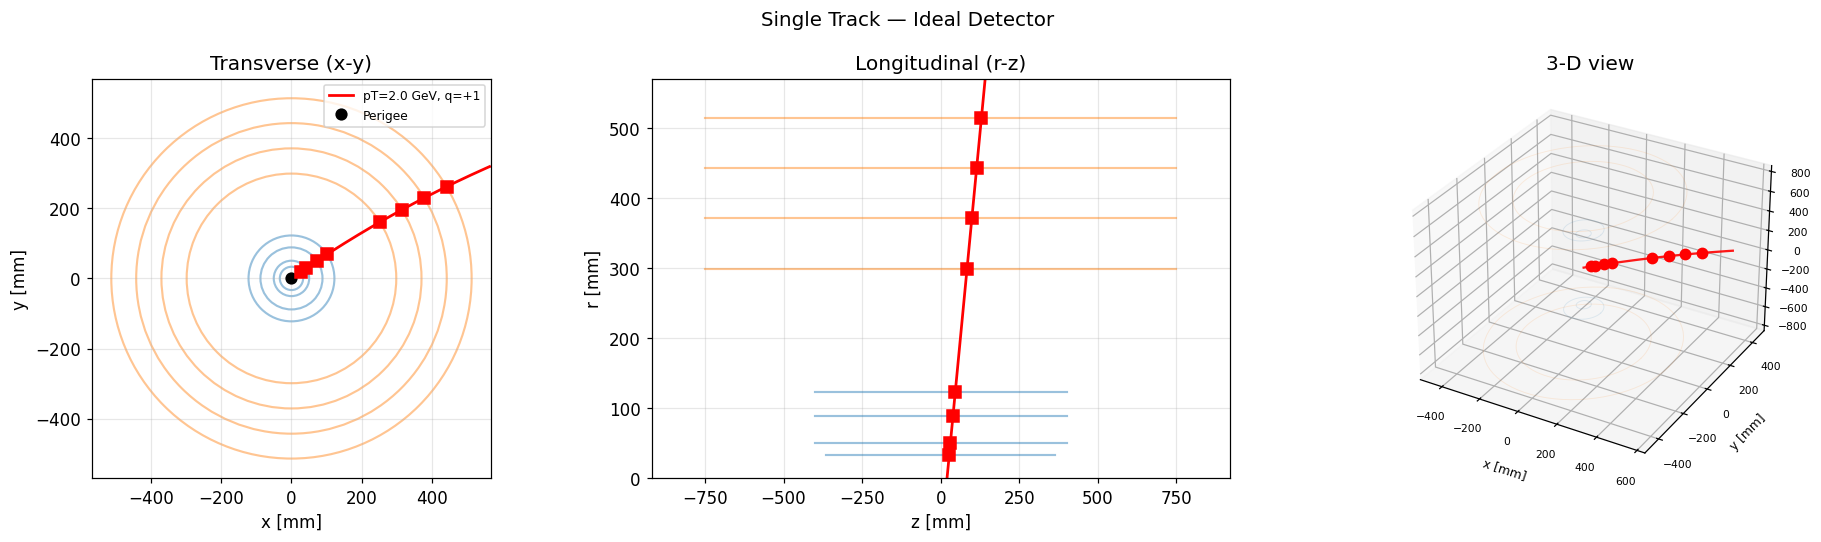

In [7]:
fig = plt.figure(figsize=(18, 5))
axes = [fig.add_subplot(1, 3, i+1, projection='3d' if i==2 else None) for i in range(3)]

s_plot = _s_vis(single, r_vis=560.0)
tx, ty, tz = single.trajectory(s_plot)
tr = np.sqrt(tx**2 + ty**2)

# ── transverse (x-y) ─────────────────────────────────────────────────────────
ax = axes[0]
det_ideal.draw_xy(ax, alpha=0.45)
ax.plot(tx, ty, "r-", lw=1.8, label=f"pT={single.pt:.1f} GeV, q={single.charge:+d}")
ax.plot(*single.position(0)[:2], "ko", ms=7, label="Perigee")
for h in hits0:
    ax.plot(h.x_true, h.y_true, "rs", ms=8, zorder=6)
ax.set_xlim(-570, 570); ax.set_ylim(-570, 570); ax.set_aspect("equal")
ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
ax.set_title("Transverse (x-y)"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# ── longitudinal (r-z) ───────────────────────────────────────────────────────
ax = axes[1]
det_ideal.draw_rz(ax, alpha=0.45)
ax.plot(tz, tr, "r-", lw=1.8)
for h in hits0:
    ax.plot(h.z_true, h.r_true, "rs", ms=8, zorder=6)
ax.set_xlim(-920, 920); ax.set_ylim(0, 570)
ax.set_xlabel("z [mm]"); ax.set_ylabel("r [mm]")
ax.set_title("Longitudinal (r-z)"); ax.grid(True, alpha=0.3)

# ── 3-D helix ────────────────────────────────────────────────────────────────
ax = axes[2]
ax.plot(tx, ty, tz, "r-", lw=1.5, alpha=0.9, label="Track")
for h in hits0:
    ax.scatter(h.x_true, h.y_true, h.z_true, c="red", s=45, zorder=6)
# Draw a few layer cylinders as rings
theta_cyl = np.linspace(0, 2 * np.pi, 80)
for lay in det_ideal.layers[::2]:
    xc_ = lay.radius * np.cos(theta_cyl)
    yc_ = lay.radius * np.sin(theta_cyl)
    for zring in (-lay.z_max, lay.z_max):
        ax.plot(xc_, yc_, zring * np.ones(80),
                color=LAYER_COLOR[lay.det_type], alpha=0.12, lw=0.6)
ax.set_xlabel("x [mm]", fontsize=8); ax.set_ylabel("y [mm]", fontsize=8)
ax.set_zlabel("z [mm]", fontsize=8); ax.set_title("3-D view"); ax.tick_params(labelsize=7)

plt.suptitle("Single Track — Ideal Detector", fontsize=13)
plt.tight_layout()
plt.savefig("single_track_ideal.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.2  Multi-track event — ideal detector

In [8]:
det_ideal = Detector()
# Use exponential p_T distribution so curvature is clearly visible
tracks_ev, hits_ev = generate_event(n_tracks=8, detector=det_ideal,
                                     pt_dist='exponential', pt_mean=0.6, pt_min=0.15,
                                     eta_range=(-1.5, 1.5), ideal=True, seed=42)

print(f"Generated {len(tracks_ev)} tracks, {len(hits_ev)} hits\n")
for trk in tracks_ev:
    n = sum(1 for h in hits_ev if h.track_id == trk.track_id)
    print(f"  {trk}  →  {n} hits")


Generated 8 tracks, 64 hits

  Track(id=00, pT=3.98 GeV, φ₀=-22.0°, η=1.08, q=-1, d₀=-0.20 mm, R=6638 mm)  →  8 hits
  Track(id=01, pT=3.93 GeV, φ₀=103.0°, η=-1.12, q=+1, d₀=-0.09 mm, R=6542 mm)  →  8 hits
  Track(id=02, pT=4.67 GeV, φ₀=51.8°, η=0.97, q=+1, d₀=-0.09 mm, R=7784 mm)  →  8 hits
  Track(id=03, pT=0.79 GeV, φ₀=117.9°, η=0.39, q=-1, d₀=-0.02 mm, R=1312 mm)  →  8 hits
  Track(id=04, pT=4.87 GeV, φ₀=141.5°, η=0.84, q=+1, d₀=0.05 mm, R=8114 mm)  →  8 hits
  Track(id=05, pT=1.19 GeV, φ₀=65.9°, η=0.73, q=-1, d₀=-0.04 mm, R=1991 mm)  →  8 hits
  Track(id=06, pT=2.17 GeV, φ₀=-11.0°, η=-0.93, q=-1, d₀=-0.08 mm, R=3612 mm)  →  8 hits
  Track(id=07, pT=3.51 GeV, φ₀=-22.6°, η=1.00, q=-1, d₀=-0.12 mm, R=5857 mm)  →  8 hits


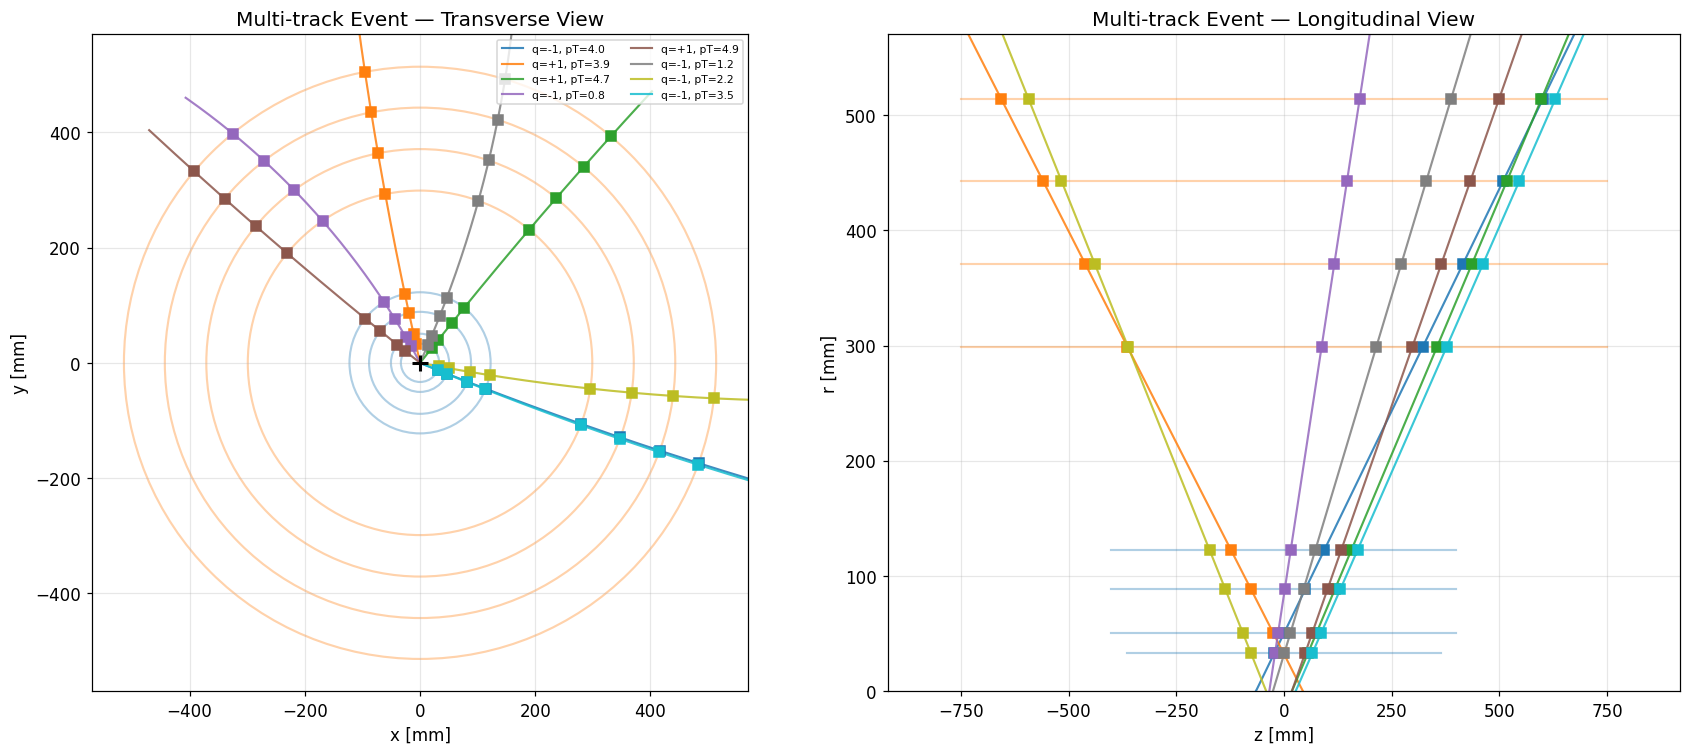

In [9]:
COLORS = plt.cm.tab10(np.linspace(0, 1, len(tracks_ev)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, view in zip(axes, ("xy", "rz")):
    if view == "xy":
        det_ideal.draw_xy(ax, alpha=0.35)
    else:
        det_ideal.draw_rz(ax, alpha=0.35)

    for trk, col in zip(tracks_ev, COLORS):
        s_plot = _s_vis(trk, r_vis=560.0)   # arc length to detector edge (or half revolution)
        tx, ty, tz = trk.trajectory(s_plot)
        tr = np.sqrt(tx**2 + ty**2)

        lbl = f"q={trk.charge:+d}, pT={trk.pt:.2f} GeV"
        if view == "xy":
            ax.plot(tx, ty, "-", color=col, lw=1.6, alpha=0.85, label=lbl)
        else:
            ax.plot(tz, tr, "-", color=col, lw=1.6, alpha=0.85)

        for h in [h for h in hits_ev if h.track_id == trk.track_id]:
            if view == "xy":
                ax.plot(h.x_true, h.y_true, "s", color=col, ms=6, zorder=5)
            else:
                ax.plot(h.z_true, h.r_true, "s", color=col, ms=6, zorder=5)

    if view == "xy":
        ax.plot(0, 0, "k+", ms=11, mew=2)
        ax.set_xlim(-570, 570); ax.set_ylim(-570, 570); ax.set_aspect("equal")
        ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
        ax.set_title("Multi-track Event — Transverse View (exponential $p_T$)")
        ax.legend(fontsize=7.5, loc="upper right", ncol=2)
    else:
        ax.set_xlim(-920, 920); ax.set_ylim(0, 570)
        ax.set_xlabel("z [mm]"); ax.set_ylabel("r [mm]")
        ax.set_title("Multi-track Event — Longitudinal View")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("multi_track_ideal.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 4  Realistic Detector <a id="4-realistic-detector"></a>

Real detectors deviate from the ideal in two important ways:

### 4.1  Intrinsic hit resolution (measurement noise)

Each hit position is smeared by the detector's intrinsic resolution:
* **Pixel** layers: $\sigma_{r\phi} = 10\,\mu\text{m}$, $\sigma_z = 115\,\mu\text{m}$
* **SCT** layers:   $\sigma_{r\phi} = 17\,\mu\text{m}$, $\sigma_z = 580\,\mu\text{m}$

Smearing is applied independently in the $r\phi$ and $z$ coordinates (Gaussian).

### 4.2  Hit inefficiency

A particle crossing a sensor is not always detected.
Typical ATLAS efficiencies are $\gtrsim97\%$ for pixel and $\gtrsim99\%$ for SCT.
We model this by dropping each hit independently with probability $1-\epsilon$.

### 4.3  Detector misalignment

Survey and alignment procedures locate module positions to finite precision.
Residual misalignments shift the apparent hit position.
We model a **rigid-body shift** of each layer's cylinder by $(dx, dy, dz)$
drawn from a Gaussian: the measured hit is displaced by the layer offset.


#### 4.1  Resolution smearing

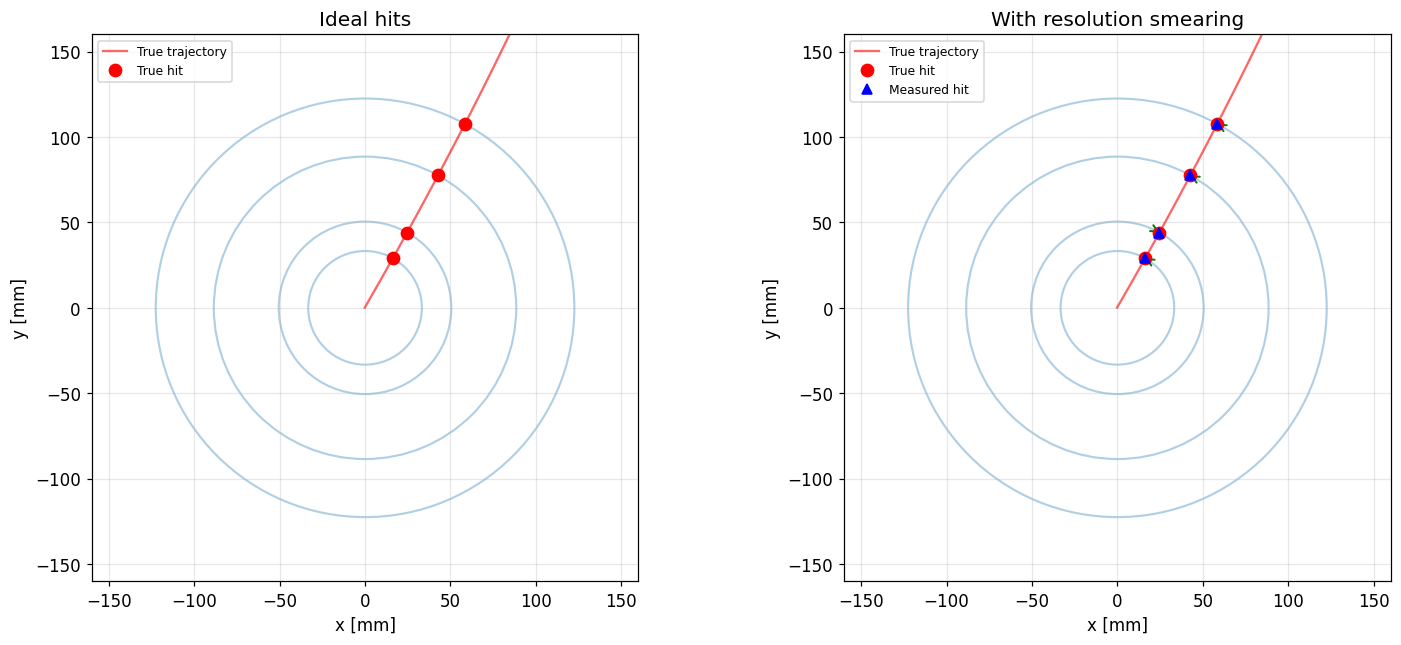


Layer       Δ(rφ) [µm]     Δz [µm]
──────────────────────────────────
IBL                3.0       -31.5
Pix-1             -4.5      -114.0
Pix-2             13.4       -56.6
Pix-3              4.9        41.0
SCT-1            -15.8       -17.0
SCT-2            -22.9      -265.4
SCT-3            -21.9     -1068.2
SCT-4            -21.5       157.3


In [10]:
Track._id_counter = 0
det_smear = Detector()   # ideal geometry, but enable smearing

smear_track = Track(pt=1.5, phi0=np.radians(60), theta=np.radians(83),
                    d0=0.2, z0=10.0, charge=-1)

hits_true   = HitGenerator(det_smear, ideal=True).generate_hits(smear_track)
hits_smear  = HitGenerator(det_smear, ideal=False).generate_hits(
                  smear_track, rng=np.random.default_rng(7))

# ── transverse view (zoomed to inner layers) ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, title, hits_plot, show_meas in [
    (axes[0], "Ideal hits",                  hits_true,  False),
    (axes[1], "With resolution smearing",    hits_smear, True),
]:
    det_smear.draw_xy(ax, alpha=0.35)
    tx, ty, _ = smear_track.trajectory(600)
    ax.plot(tx, ty, "r-", lw=1.5, alpha=0.6, label="True trajectory")
    for i, h in enumerate(hits_plot):
        kw = dict(zorder=5)
        ax.plot(h.x_true, h.y_true, "ro", ms=8, **kw,
                label="True hit" if i == 0 else "")
        if show_meas:
            ax.plot(h.x_meas, h.y_meas, "b^", ms=6, zorder=6,
                    label="Measured hit" if i == 0 else "")
            ax.annotate("", xy=(h.x_meas, h.y_meas),
                        xytext=(h.x_true, h.y_true),
                        arrowprops=dict(arrowstyle="->", color="green", lw=1.3))
    ax.set_xlim(-160, 160); ax.set_ylim(-160, 160); ax.set_aspect("equal")
    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]"); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("resolution_smearing.png", dpi=150, bbox_inches="tight")
plt.show()

# Print r·φ and z residuals
print(f"\n{'Layer':<8}  {'Δ(rφ) [µm]':>12}  {'Δz [µm]':>10}")
print("─" * 34)
for h in hits_smear:
    dphi  = h.phi_meas - h.phi_true
    drphi = h.r_true * dphi * 1e3    # µm
    dz    = (h.z_meas - h.z_true) * 1e3
    print(f"{h.layer_name:<8}  {drphi:>12.1f}  {dz:>10.1f}")


#### 4.2  Hit inefficiency

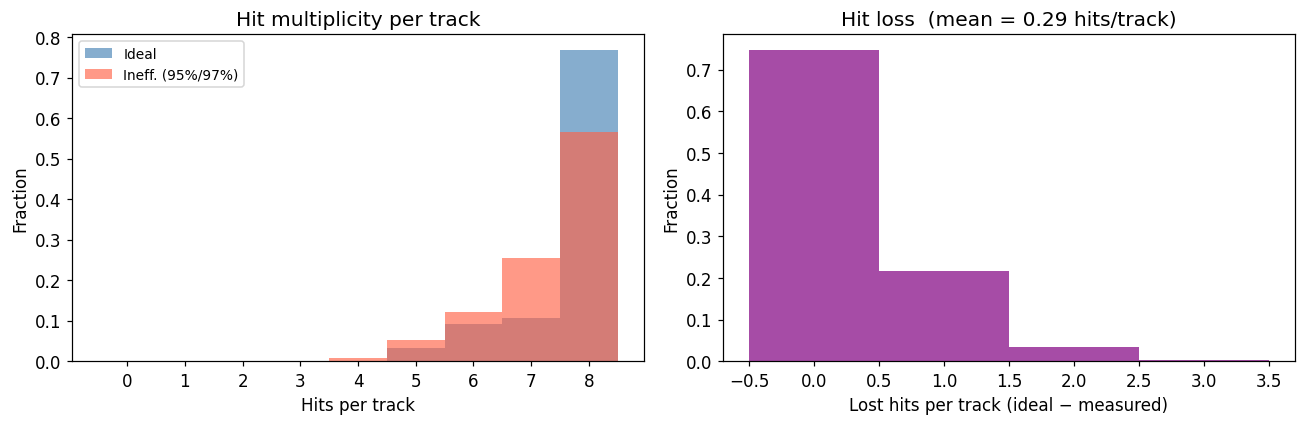

Mean hits: ideal = 7.61,  with ineff. = 7.32


In [11]:
# Study hit multiplicity with and without inefficiency (1 000 single-track events)
N_TEST  = 1_000
n_ideal = []
n_ineff = []

rng_test = np.random.default_rng(0)
for _ in range(N_TEST):
    Track._id_counter = 0
    pt_    = _sample_pt(rng_test, 'exponential', 0.6, 0.15, (0.5, 10.0))
    phi_   = rng_test.uniform(-np.pi, np.pi)
    eta_   = rng_test.uniform(-1.5, 1.5)
    theta_ = 2 * np.arctan(np.exp(-eta_))
    q_     = rng_test.choice([-1, 1])

    trk_i = Track(pt=pt_, phi0=phi_, theta=theta_, charge=q_)
    det_i = Detector()
    n_ideal.append(len(HitGenerator(det_i, ideal=True).generate_hits(trk_i)))

    Track._id_counter = 0
    trk_r = Track(pt=pt_, phi0=phi_, theta=theta_, charge=q_)
    det_r = Detector()
    det_r.apply_inefficiency(eff_pixel=0.95, eff_strip=0.97)
    n_ineff.append(len(HitGenerator(det_r, ideal=False)
                       .generate_hits(trk_r, rng=rng_test)))

diff = np.array(n_ideal) - np.array(n_ineff)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins_n = np.arange(-0.5, 9.5, 1)
axes[0].hist(n_ideal, bins=bins_n, alpha=0.65, label="Ideal",            color="steelblue", density=True)
axes[0].hist(n_ineff, bins=bins_n, alpha=0.65, label="Ineff. (95%/97%)", color="tomato",    density=True)
axes[0].set_xlabel("Hits per track"); axes[0].set_ylabel("Fraction")
axes[0].set_title("Hit multiplicity per track")
axes[0].legend(fontsize=9); axes[0].set_xticks(range(9))

axes[1].hist(diff, bins=np.arange(-0.5, diff.max()+1.5), alpha=0.7, color="purple", density=True)
axes[1].set_xlabel("Lost hits per track (ideal − measured)")
axes[1].set_ylabel("Fraction")
axes[1].set_title(f"Hit loss  (mean = {diff.mean():.2f} hits/track)")

plt.tight_layout()
plt.savefig("inefficiency.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Mean hits: ideal = {np.mean(n_ideal):.2f},  with ineff. = {np.mean(n_ineff):.2f}")


#### 4.3  Misalignment

Applied layer misalignments:
Layer       dx [µm]    dy [µm]    dz [µm]   |d_T| [µm]
────────────────────────────────────────────────────
IBL               8        -46         25           47
Pix-1            69       -176        842          189
Pix-2           -46        -60       -523           75
Pix-3            93         67        622          115
SCT-1           179         53        329          186
SCT-2           187       -176        -46          257
SCT-3            76        -91        722          118
SCT-4           -70        135        141          152


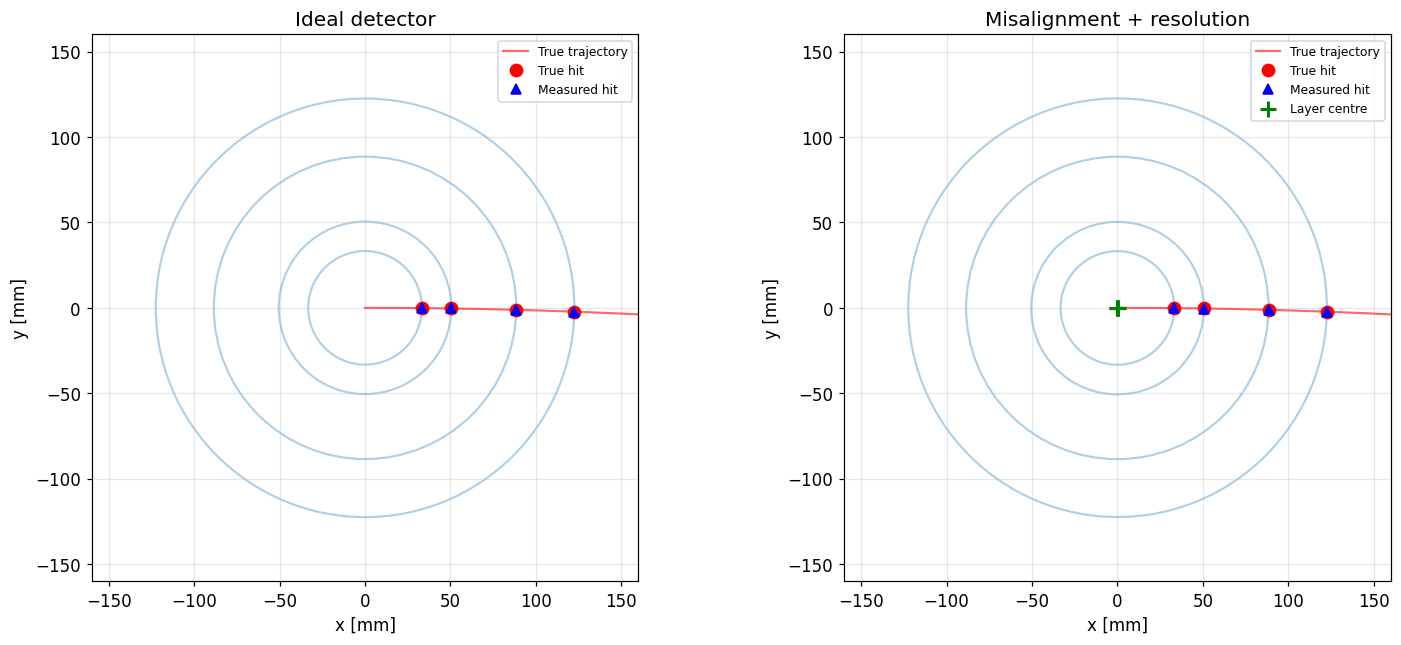

In [12]:
Track._id_counter = 0
det_mis = Detector()
det_mis.apply_misalignment(sigma_pixel_mm=0.10, sigma_strip_mm=0.20, seed=99)

print("Applied layer misalignments:")
print(f"{'Layer':<8}  {'dx [µm]':>9}  {'dy [µm]':>9}  {'dz [µm]':>9}  {'|d_T| [µm]':>11}")
print("─" * 52)
for lay in det_mis.layers:
    dt = np.sqrt(lay.dx**2 + lay.dy**2) * 1e3
    print(f"{lay.name:<8}  {lay.dx*1e3:>9.0f}  {lay.dy*1e3:>9.0f}  "
          f"{lay.dz*1e3:>9.0f}  {dt:>11.0f}")

# Compare ideal vs misaligned for the same track (zoom to pixel region)
trk_mis = Track(pt=2.0, phi0=np.radians(0), theta=np.radians(85), charge=1)
hits_idl = HitGenerator(Detector(),  ideal=True ).generate_hits(trk_mis)
Track._id_counter = 0
trk_mis2 = Track(pt=2.0, phi0=np.radians(0), theta=np.radians(85), charge=1)
hits_mis  = HitGenerator(det_mis, ideal=False).generate_hits(
                trk_mis2, rng=np.random.default_rng(42))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, hits_plot, det_plot, title, show_mis in [
    (axes[0], hits_idl, Detector(),  "Ideal detector",                False),
    (axes[1], hits_mis, det_mis,     "Misalignment + resolution",     True),
]:
    det_plot.draw_xy(ax, ideal=(not show_mis), alpha=0.35)
    tx, ty, _ = trk_mis.trajectory(600)
    ax.plot(tx, ty, "r-", lw=1.4, alpha=0.6, label="True trajectory")
    for i, h in enumerate(hits_plot):
        ax.plot(h.x_true, h.y_true, "ro", ms=8, zorder=5,
                label="True hit" if i == 0 else "")
        ax.plot(h.x_meas, h.y_meas, "b^", ms=6, zorder=6,
                label="Measured hit" if i == 0 else "")
    if show_mis:
        for lay in det_plot.layers[:4]:   # pixel layers
            ax.plot(lay.dx, lay.dy, "g+", ms=10, mew=2,
                    label="Layer centre" if lay == det_plot.layers[0] else "")
    ax.set_xlim(-160, 160); ax.set_ylim(-160, 160); ax.set_aspect("equal")
    ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]"); ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("misalignment.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.4  Summary — ideal vs fully distorted event

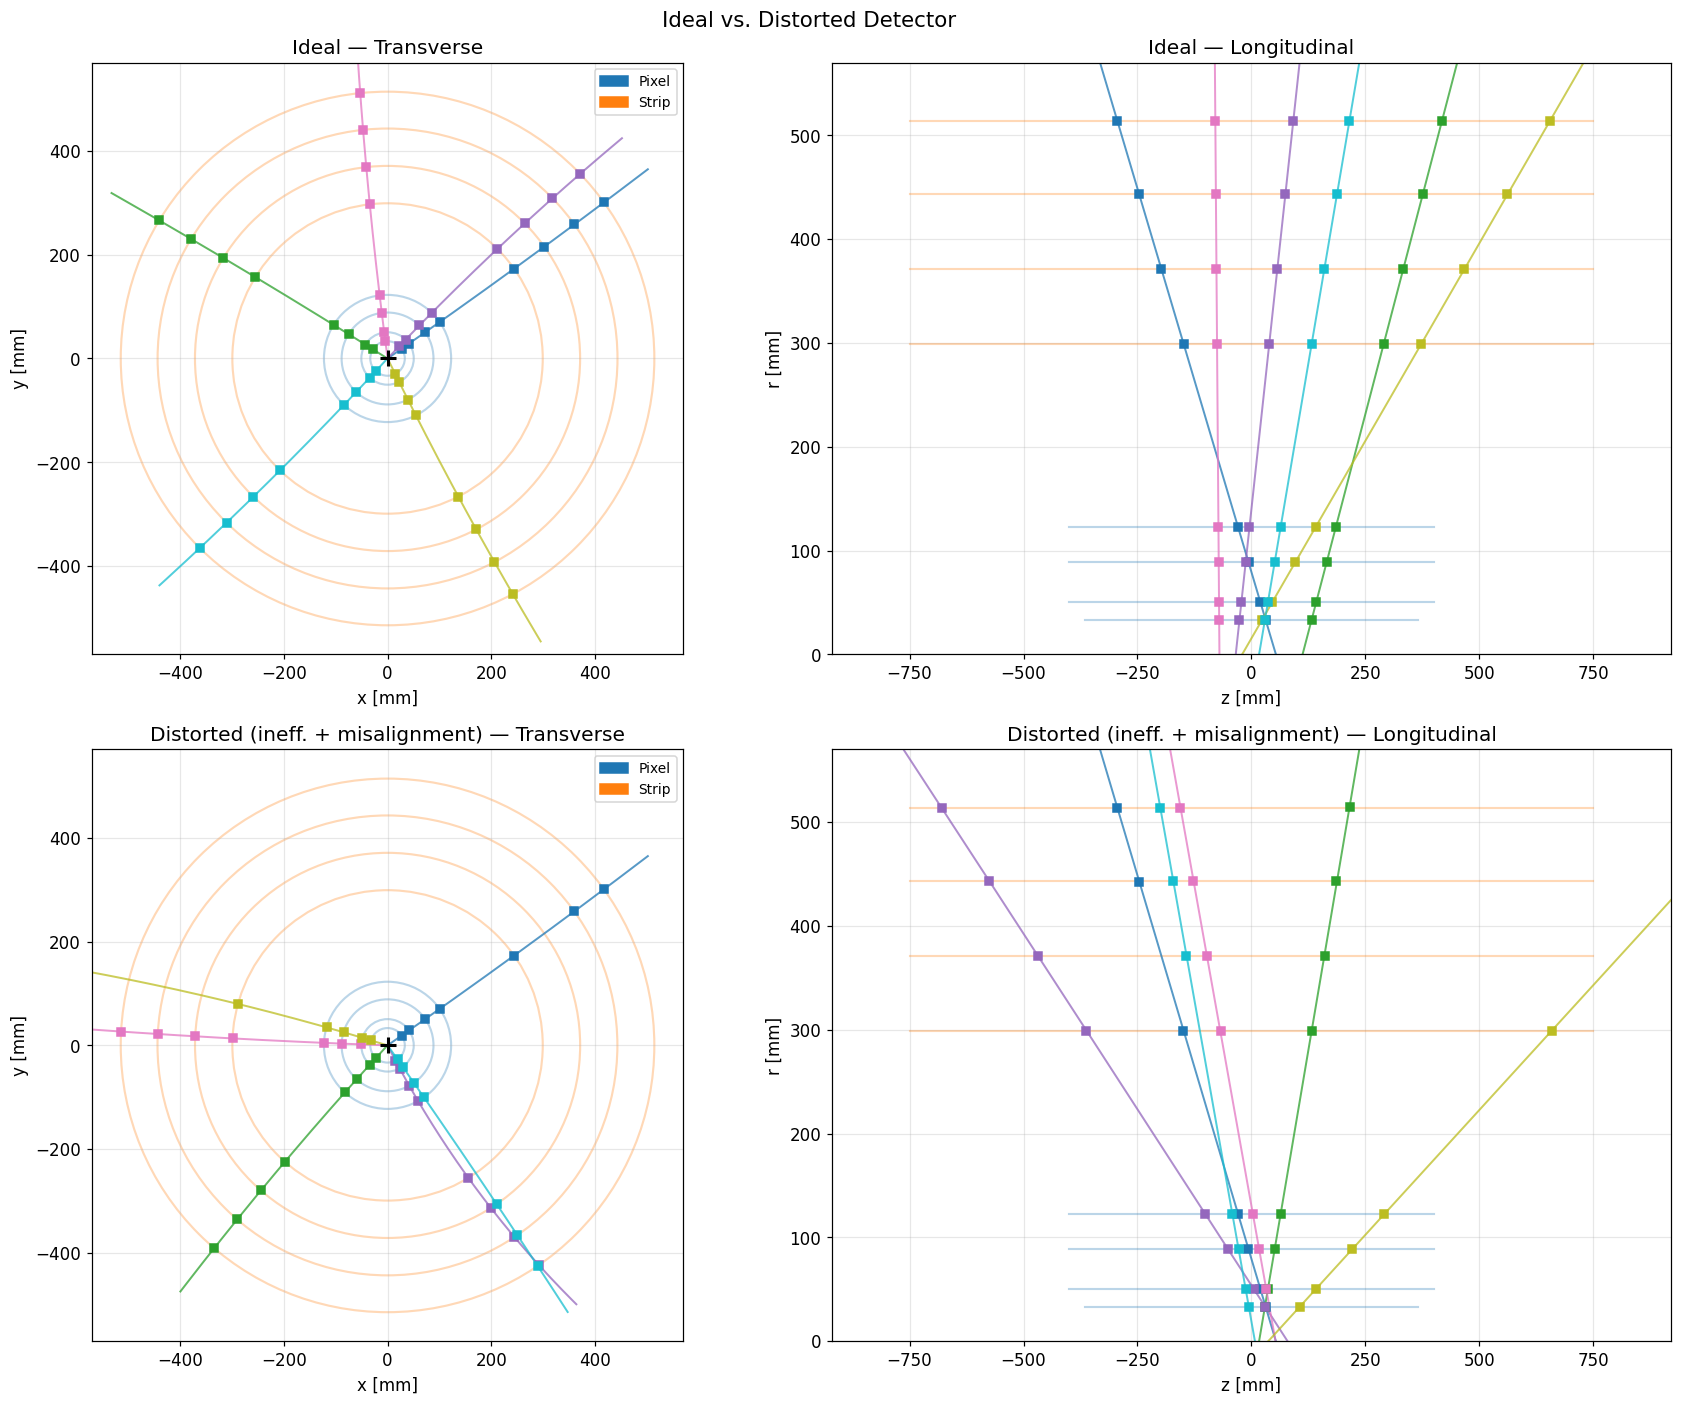

     Ideal: mean 8.0 hits / track
 Distorted: mean 7.0 hits / track


In [13]:
det_id  = Detector()
det_dis = Detector()
det_dis.apply_misalignment(sigma_pixel_mm=0.05, sigma_strip_mm=0.10, seed=7)
det_dis.apply_inefficiency(eff_pixel=0.95, eff_strip=0.97)

tracks_id, hits_id   = generate_event(n_tracks=6, detector=det_id,
                                       pt_dist='exponential', pt_mean=0.6, pt_min=0.15,
                                       ideal=True,  seed=100)
tracks_dis, hits_dis = generate_event(n_tracks=6, detector=det_dis,
                                       pt_dist='exponential', pt_mean=0.6, pt_min=0.15,
                                       ideal=False, seed=100)

COLS6 = plt.cm.tab10(np.linspace(0, 1, 6))
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

for row, (tracks, hits, det_, lbl) in enumerate([
    (tracks_id,  hits_id,  det_id,  "Ideal"),
    (tracks_dis, hits_dis, det_dis, "Distorted (ineff. + misalignment)"),
]):
    for col, view in enumerate(("xy", "rz")):
        ax = axes[row][col]
        if view == "xy":
            det_.draw_xy(ax, ideal=(row==0), alpha=0.30)
        else:
            det_.draw_rz(ax, ideal=(row==0), alpha=0.30)

        for trk, col_ in zip(tracks, COLS6):
            s_max = _s_vis(trk, r_vis=560.0)
            tx, ty, tz = trk.trajectory(s_max)
            tr = np.sqrt(tx**2 + ty**2)
            if view == "xy":
                ax.plot(tx, ty, "-", color=col_, lw=1.3, alpha=0.75)
            else:
                ax.plot(tz, tr, "-", color=col_, lw=1.3, alpha=0.75)
            for h in [h for h in hits if h.track_id == trk.track_id]:
                if view == "xy":
                    ax.plot(h.x_meas, h.y_meas, "s", color=col_, ms=5, zorder=5)
                else:
                    ax.plot(h.z_meas, h.r_meas, "s", color=col_, ms=5, zorder=5)

        if view == "xy":
            ax.plot(0, 0, "k+", ms=10, mew=2)
            ax.set_xlim(-570, 570); ax.set_ylim(-570, 570); ax.set_aspect("equal")
            ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
            ax.set_title(f"{lbl} — Transverse")
        else:
            ax.set_xlim(-920, 920); ax.set_ylim(0, 570)
            ax.set_xlabel("z [mm]"); ax.set_ylabel("r [mm]")
            ax.set_title(f"{lbl} — Longitudinal")
        ax.grid(True, alpha=0.3)

plt.suptitle("Ideal vs. Distorted Detector", fontsize=14)
plt.tight_layout()
plt.savefig("comparison_ideal_vs_distorted.png", dpi=150, bbox_inches="tight")
plt.show()

for label, tracks_, hits_ in [("Ideal", tracks_id, hits_id), ("Distorted", tracks_dis, hits_dis)]:
    mean_h = np.mean([sum(1 for h in hits_ if h.track_id == t.track_id) for t in tracks_])
    print(f"{label:>10}: mean {mean_h:.1f} hits / track")


---
## 5  Exercise Dataset <a id="5-exercise-dataset"></a>

We generate two labelled datasets:

| File | Content |
|---|---|
| `hits_ideal.csv` | Perfect hits — good starting point for debugging a tracking algorithm |
| `hits_distorted.csv` | Realistic hits with smearing, inefficiency and misalignment |
| `truth_ideal.csv` | True track parameters for the ideal set |
| `truth_distorted.csv` | True track parameters for the distorted set |

### Task for the student

1. **Pattern recognition / track finding**: cluster hits into track candidates
   (e.g.\ Hough transform, cellular automaton, nearest-neighbour graph, …)
2. **Track fitting**: fit helix parameters to the assigned hits
   (e.g.\ least-squares circle fit in transverse plane + linear $z$ fit)
3. **Performance evaluation**: compare fitted parameters to truth,
   compute tracking efficiency and fake rate

The hit files contain only measured positions — no truth assignment.
Truth files are provided separately for validation.


In [14]:
os.makedirs("exercise_data", exist_ok=True)

def generate_dataset(n_events:           int   = 200,
                     n_tracks_mean:      float = 10.0,   # Poisson mean per event
                     distorted:          bool  = True,
                     seed:               int   = 0,
                     output_dir:         str   = "exercise_data"
                     ) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Produce a tracking exercise dataset and write CSV files.

    Track kinematics per event
    --------------------------
    * Multiplicity:  Poisson(n_tracks_mean)  (≥ 1)
    * p_T:           Exponential(0.6 GeV), truncated at 0.15 GeV
    * η:             Uniform in [-1.5, 1.5]

    Parameters
    ----------
    n_events       : number of collision events
    n_tracks_mean  : Poisson mean of charged-particle multiplicity per event
    distorted      : apply realistic distortions (smearing, inefficiency, misalignment)
    seed           : RNG seed
    output_dir     : directory for CSV output

    Returns
    -------
    (hits_df, truth_df)
    """
    # One fixed detector configuration per dataset
    # (constant misalignment — simulates uncalibrated detector)
    det = Detector()
    if distorted:
        det.apply_misalignment(sigma_pixel_mm=0.05, sigma_strip_mm=0.10, seed=seed)
        det.apply_inefficiency(eff_pixel=0.97, eff_strip=0.99)

    rng   = np.random.default_rng(seed)
    Track._id_counter = 0

    hit_rows:   List[dict] = []
    truth_rows: List[dict] = []

    for ev in range(n_events):
        ev_seed = int(rng.integers(0, 1_000_000))
        tracks, hits = generate_event(
            n_tracks      = None,           # Poisson multiplicity
            n_tracks_mean = n_tracks_mean,
            detector      = det,
            pt_dist       = 'exponential',
            pt_mean       = 0.6,
            pt_min        = 0.15,
            eta_range     = (-1.5, 1.5),
            ideal         = not distorted,
            seed          = ev_seed,
        )
        for h in hits:
            hit_rows.append({
                "event_id":   ev,
                "hit_id":     h.hit_id,
                "layer_id":   h.layer_id,
                "layer_name": h.layer_name,
                "x":          round(h.x_meas, 5),
                "y":          round(h.y_meas, 5),
                "z":          round(h.z_meas, 5),
                "r":          round(h.r_meas, 5),
                "phi":        round(h.phi_meas, 6),
            })
        for trk in tracks:
            trk_hits = [h for h in hits if h.track_id == trk.track_id]
            truth_rows.append({
                "event_id":   ev,
                "track_id":   trk.track_id,
                "pt_GeV":     round(trk.pt,   4),
                "phi0_rad":   round(trk.phi0, 6),
                "theta_rad":  round(trk.theta, 6),
                "eta":        round(trk.eta,   4),
                "d0_mm":      round(trk.d0,    4),
                "z0_mm":      round(trk.z0,    4),
                "charge":     trk.charge,
                "n_hits":     len(trk_hits),
                "hit_ids":    " ".join(str(h.hit_id) for h in trk_hits),
            })

    hits_df  = pd.DataFrame(hit_rows)
    truth_df = pd.DataFrame(truth_rows)

    tag = "distorted" if distorted else "ideal"
    hits_df.to_csv(f"{output_dir}/hits_{tag}.csv",   index=False)
    truth_df.to_csv(f"{output_dir}/truth_{tag}.csv", index=False)
    n_trk_mean = len(truth_df) / n_events
    n_hit_mean = len(hits_df)  / n_events
    print(f"[{tag:>10}]  {len(hits_df):>6} hits  |  {len(truth_df):>5} tracks  |  "
          f"{n_events} events  |  "
          f"⟨n_trk⟩={n_trk_mean:.1f}, ⟨n_hit/ev⟩={n_hit_mean:.1f}  →  {output_dir}/")
    return hits_df, truth_df


print("Generating datasets with realistic kinematics…")
hits_id_df,  truth_id_df  = generate_dataset(distorted=False, seed=42)
hits_dis_df, truth_dis_df = generate_dataset(distorted=True,  seed=42)

# Sanity check: p_T distribution in the generated dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, (df, lbl) in zip(axes, [(truth_id_df, "ideal"), (truth_dis_df, "distorted")]):
    ax.hist(df["pt_GeV"], bins=np.linspace(0, 5, 60), density=True,
            color="steelblue", alpha=0.7)
    ax.set_xlabel(r"$p_T$  [GeV]"); ax.set_ylabel("Density"); ax.set_title(f"Dataset: {lbl}")
    ax.set_xlim(0, 5); ax.grid(True, alpha=0.3)
    ax.text(0.98, 0.96, f"⟨pT⟩={df['pt_GeV'].mean():.2f} GeV",
            transform=ax.transAxes, ha="right", va="top", fontsize=9)
plt.tight_layout()
plt.show()


Generating datasets…
[     ideal]    7627 hits  |  1000 tracks  |  200 events  →  exercise_data/
[ distorted]    7458 hits  |  1000 tracks  |  200 events  →  exercise_data/


### 5.1  Inspect the output

In [15]:
print("=== hits_distorted.csv — first event ===")
ev0 = hits_dis_df[hits_dis_df.event_id == 0]
print(ev0[["hit_id","layer_id","layer_name","x","y","z","r"]].to_string(index=False))

print("\n=== truth_distorted.csv — first event ===")
t0 = truth_dis_df[truth_dis_df.event_id == 0]
print(t0[["track_id","pt_GeV","phi0_rad","eta","d0_mm","charge","n_hits"]].to_string(index=False))

print("\n=== Dataset statistics ===")
print(f"Ideal:     {hits_id_df.groupby('event_id').size().describe()[['mean','min','max']].to_dict()}")
print(f"Distorted: {hits_dis_df.groupby('event_id').size().describe()[['mean','min','max']].to_dict()}")


=== hits_distorted.csv — first event ===
 hit_id  layer_id layer_name          x          y          z         r
      0         0        IBL  -22.29679  -24.70430   -7.00166  33.27836
      1         1      Pix-1  -33.71641  -37.65125    4.23530  50.54120
      2         2      Pix-2  -58.89874  -66.06455   29.55501  88.50755
      3         3      Pix-3  -81.29697  -91.62928   52.15407 122.49540
      4         4      SCT-1 -195.21558 -226.35868  169.79377 298.91032
      5         5      SCT-2 -240.82417 -282.25039  216.20535 371.02771
      6         6      SCT-3 -285.57278 -338.60063  263.80717 442.94718
      7         7      SCT-4 -329.48399 -394.44227  312.86095 513.94981
      8         0        IBL    7.95523  -32.34006 -120.42428  33.30413
      9         1      Pix-1   12.27046  -49.09590 -131.63451  50.60604
     10         2      Pix-2   21.92278  -85.75916 -155.07183  88.51690
     11         3      Pix-3   30.96361 -118.46705 -176.24959 122.44667
     12         4      

---
## Notes on implementing a tracking algorithm

Below are hints for students implementing the tracking exercise.

### Suggested approach: circle fit in the transverse plane

For a set of hits $(x_i, y_i)$, find the circle $(x-x_c)^2 + (y-y_c)^2 = R^2$
that minimises the sum of squared residuals.  This gives $p_T$ and $\phi_0$.

A fast linear method: expand the circle equation
$$x_c^2 + y_c^2 - R^2 \equiv -D$$
to get $x^2 + y^2 + Dx + Ey + F = 0$ and solve the over-determined linear system
for $(D, E, F)$ with least squares.  Then
$$x_c = -D/2,\quad y_c = -E/2,\quad R = \tfrac{1}{2}\sqrt{D^2+E^2-4F}$$

### Suggested approach: $z$ vs. arc-length fit

Once the circle is found, compute the arc length $s_i$ for each hit and fit a
straight line $z_i = z_0 + s_i \cot\theta$ to extract $z_0$ and $\theta$.

### Performance metrics

- **Tracking efficiency**: fraction of truth tracks with at least one matched reconstructed track
- **Fake rate**: fraction of reconstructed tracks not matched to any truth track
- **Resolution**: RMS of (fitted – truth) for each track parameter
